# 💰 Customer & Revenue Analytics
## Part 1 — RFM Segmentation & Revenue Analysis

**Author:** Kawtar Barouti  
**Dataset:** Brazilian E-Commerce by Olist (100K+ orders, 8 relational tables)  
**Objective:** Segment customers by value (RFM) and identify revenue concentration patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

COLORS = ['#1B3A5C', '#2E75B6', '#C49A2D', '#2D8B4E', '#C0392B', '#8E44AD']
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load All Tables into SQLite

In [2]:
import glob

conn = sqlite3.connect('../data/olist.db')

csv_files = glob.glob('../data/olist_*.csv') + glob.glob('../data/product_*.csv')
for f in csv_files:
    table_name = f.split('/')[-1].split('\\')[-1].replace('.csv', '')
    df_temp = pd.read_csv(f)
    df_temp.to_sql(table_name, conn, if_exists='replace', index=False)
    print(f'  ✓ {table_name}: {len(df_temp):,} rows')

print(f'\nAll tables loaded into olist.db ✓')

  ✓ olist_customers_dataset: 99,441 rows
  ✓ olist_geolocation_dataset: 1,000,163 rows
  ✓ olist_orders_dataset: 99,441 rows
  ✓ olist_order_items_dataset: 112,650 rows
  ✓ olist_order_payments_dataset: 103,886 rows
  ✓ olist_order_reviews_dataset: 99,224 rows
  ✓ olist_products_dataset: 32,951 rows
  ✓ olist_sellers_dataset: 3,095 rows
  ✓ product_category_name_translation: 71 rows

All tables loaded into olist.db ✓


## 2. Dataset Overview

In [3]:
# Quick overview of key tables
tables_info = pd.read_sql("""
    SELECT name, 
           (SELECT COUNT(*) FROM pragma_table_info(name)) as columns
    FROM sqlite_master 
    WHERE type='table'
    ORDER BY name
""", conn)

for _, row in tables_info.iterrows():
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM [{row['name']}]", conn).iloc[0, 0]
    print(f"  {row['name']}: {count:,} rows, {row['columns']} columns")

  olist_customers_dataset: 99,441 rows, 0 columns
  olist_geolocation_dataset: 1,000,163 rows, 0 columns
  olist_order_items_dataset: 112,650 rows, 0 columns
  olist_order_payments_dataset: 103,886 rows, 0 columns
  olist_order_reviews_dataset: 99,224 rows, 0 columns
  olist_orders_dataset: 99,441 rows, 0 columns
  olist_products_dataset: 32,951 rows, 0 columns
  olist_sellers_dataset: 3,095 rows, 0 columns
  product_category_name_translation: 71 rows, 0 columns


In [4]:
# Key metrics
stats = pd.read_sql("""
    SELECT 
        COUNT(DISTINCT o.order_id) AS total_orders,
        COUNT(DISTINCT c.customer_unique_id) AS unique_customers,
        ROUND(SUM(p.payment_value), 2) AS total_revenue,
        ROUND(AVG(p.payment_value), 2) AS avg_order_value,
        MIN(o.order_purchase_timestamp) AS first_order,
        MAX(o.order_purchase_timestamp) AS last_order
    FROM olist_orders_dataset o
    JOIN olist_customers_dataset c ON o.customer_id = c.customer_id
    JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
""", conn)

print('=' * 55)
print('       CUSTOMER & REVENUE KPI OVERVIEW')
print('=' * 55)
print(f'  Total Orders:         {stats["total_orders"].iloc[0]:>12,}')
print(f'  Unique Customers:     {stats["unique_customers"].iloc[0]:>12,}')
print(f'  Total Revenue:        R${stats["total_revenue"].iloc[0]:>12,.2f}')
print(f'  Avg Order Value:      R${stats["avg_order_value"].iloc[0]:>12,.2f}')
print(f'  Period:               {stats["first_order"].iloc[0][:10]} → {stats["last_order"].iloc[0][:10]}')
print('=' * 55)

       CUSTOMER & REVENUE KPI OVERVIEW
  Total Orders:               96,477
  Unique Customers:           93,357
  Total Revenue:        R$15,422,461.77
  Avg Order Value:      R$      153.07
  Period:               2016-10-03 → 2018-08-29


## 3. RFM Segmentation (SQL + Python)

In [5]:
# RFM Calculation via SQL
rfm_df = pd.read_sql("""
    WITH rfm AS (
        SELECT
            c.customer_unique_id,
            CAST(julianday('2018-10-01') - julianday(MAX(o.order_purchase_timestamp))
                 AS INTEGER) AS recency,
            COUNT(DISTINCT o.order_id) AS frequency,
            ROUND(SUM(p.payment_value), 2) AS monetary
        FROM olist_customers_dataset c
        JOIN olist_orders_dataset o ON c.customer_id = o.customer_id
        JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY c.customer_unique_id
    )
    SELECT * FROM rfm
""", conn)

print(f'RFM calculated for {len(rfm_df):,} unique customers')
print(f'\nRFM Statistics:')
rfm_df[['recency', 'frequency', 'monetary']].describe().round(1)

RFM calculated for 93,357 unique customers

RFM Statistics:


,recency,frequency,monetary
count,93357.0,93357.0,93357.0
mean,269.5,1.0,165.2
std,152.6,0.2,226.3
min,32.0,1.0,9.6
25%,146.0,1.0,63.1
50%,250.0,1.0,107.8
75%,378.0,1.0,182.6
max,727.0,15.0,13664.1


In [6]:
# Score RFM using quintiles (1-5)
rfm_df['r_score'] = pd.qcut(rfm_df['recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm_df['f_score'] = pd.qcut(rfm_df['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm_df['m_score'] = pd.qcut(rfm_df['monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

# Create segments
def rfm_segment(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4:
        return 'Champions'
    elif row['r_score'] >= 3 and row['f_score'] >= 3:
        return 'Loyal Customers'
    elif row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'New Customers'
    elif row['r_score'] <= 2 and row['f_score'] >= 3:
        return 'At Risk'
    elif row['r_score'] <= 2 and row['f_score'] <= 2:
        return 'Lost'
    else:
        return 'Potential Loyalists'

rfm_df['segment'] = rfm_df.apply(rfm_segment, axis=1)

# Segment summary
seg_summary = rfm_df.groupby('segment').agg(
    customers=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(1).sort_values('total_revenue', ascending=False)

seg_summary['pct_customers'] = (seg_summary['customers'] / seg_summary['customers'].sum() * 100).round(1)
seg_summary['pct_revenue'] = (seg_summary['total_revenue'] / seg_summary['total_revenue'].sum() * 100).round(1)

print('\n📊 RFM SEGMENT SUMMARY')
print('=' * 80)
seg_summary


📊 RFM SEGMENT SUMMARY


,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_customers,pct_revenue
segment,,,,,,,
At Risk,22153,426.6,1.0,167.0,3700331.2,23.7,24.0
Loyal Customers,18852,200.7,1.0,161.2,3039803.2,20.2,19.7
Champions,15009,122.0,1.1,177.0,2655895.8,16.1,17.2
New Customers,15037,122.7,1.0,163.6,2459716.9,16.1,15.9
Lost,14922,427.6,1.0,162.8,2429330.8,16.0,15.8
Potential Loyalists,7384,252.5,1.0,154.0,1137383.9,7.9,7.4


## 4. Visualizations

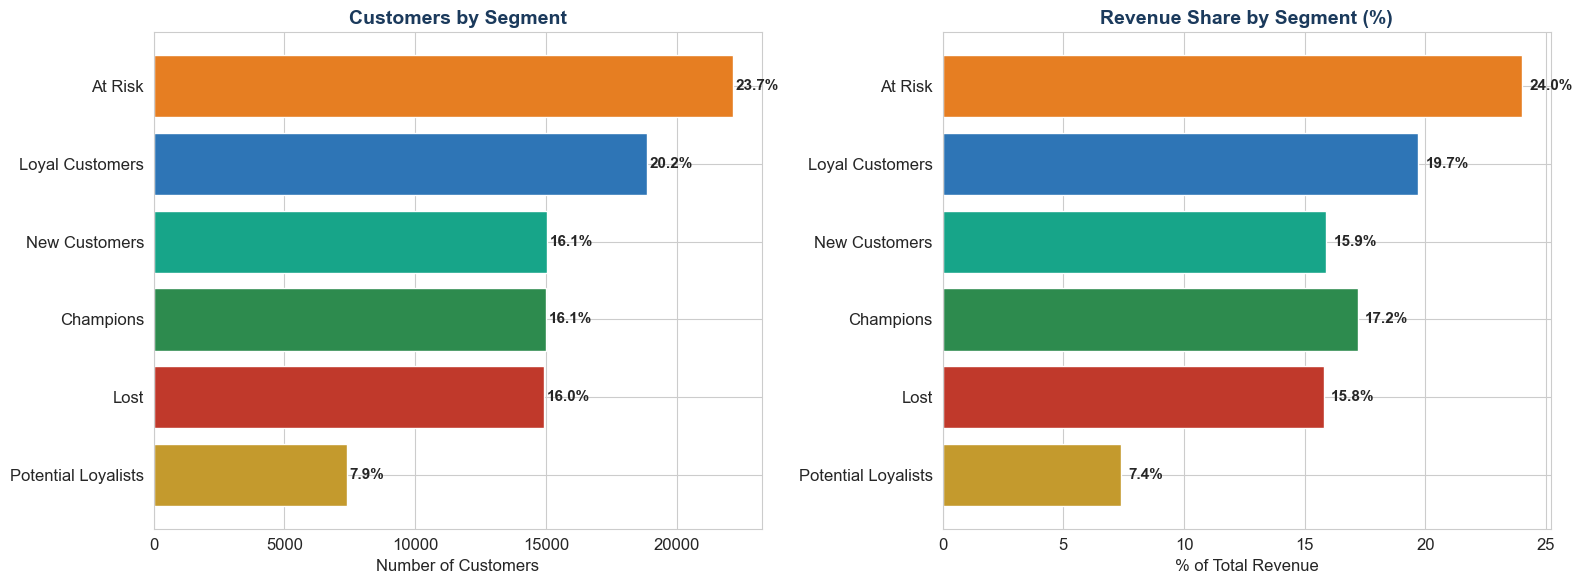

Saved → visuals/rfm_segments.png ✓


In [7]:
# Chart 1: Customer Distribution by Segment
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

seg_colors = {'Champions': '#2D8B4E', 'Loyal Customers': '#2E75B6', 
              'Potential Loyalists': '#C49A2D', 'New Customers': '#17A589',
              'At Risk': '#E67E22', 'Lost': '#C0392B'}

seg_data = seg_summary.sort_values('customers', ascending=True)
colors = [seg_colors.get(s, '#888888') for s in seg_data.index]

# Customer count
bars = axes[0].barh(seg_data.index, seg_data['customers'], color=colors, edgecolor='white')
for bar, pct in zip(bars, seg_data['pct_customers']):
    axes[0].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', va='center', fontweight='bold', fontsize=11)
axes[0].set_title('Customers by Segment', fontsize=14, fontweight='bold', color='#1B3A5C')
axes[0].set_xlabel('Number of Customers')

# Revenue share
bars2 = axes[1].barh(seg_data.index, seg_data['pct_revenue'], color=colors, edgecolor='white')
for bar, val in zip(bars2, seg_data['pct_revenue']):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)
axes[1].set_title('Revenue Share by Segment (%)', fontsize=14, fontweight='bold', color='#1B3A5C')
axes[1].set_xlabel('% of Total Revenue')

plt.tight_layout()
plt.savefig('../visuals/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/rfm_segments.png ✓')

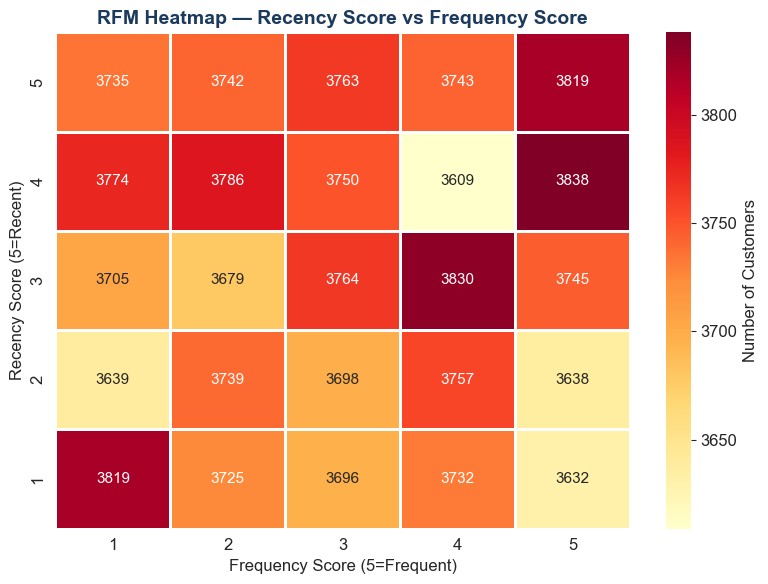

Saved → visuals/rfm_heatmap.png ✓


In [8]:
# Chart 2: RFM Heatmap (R score vs F score)
rfm_heatmap = rfm_df.groupby(['r_score', 'f_score']).size().reset_index(name='count')
pivot = rfm_heatmap.pivot(index='r_score', columns='f_score', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=2,
            linecolor='white', cbar_kws={'label': 'Number of Customers'},
            annot_kws={'fontsize': 11}, ax=ax)
ax.set_title('RFM Heatmap — Recency Score vs Frequency Score',
             fontsize=14, fontweight='bold', color='#1B3A5C')
ax.set_ylabel('Recency Score (5=Recent)')
ax.set_xlabel('Frequency Score (5=Frequent)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../visuals/rfm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/rfm_heatmap.png ✓')

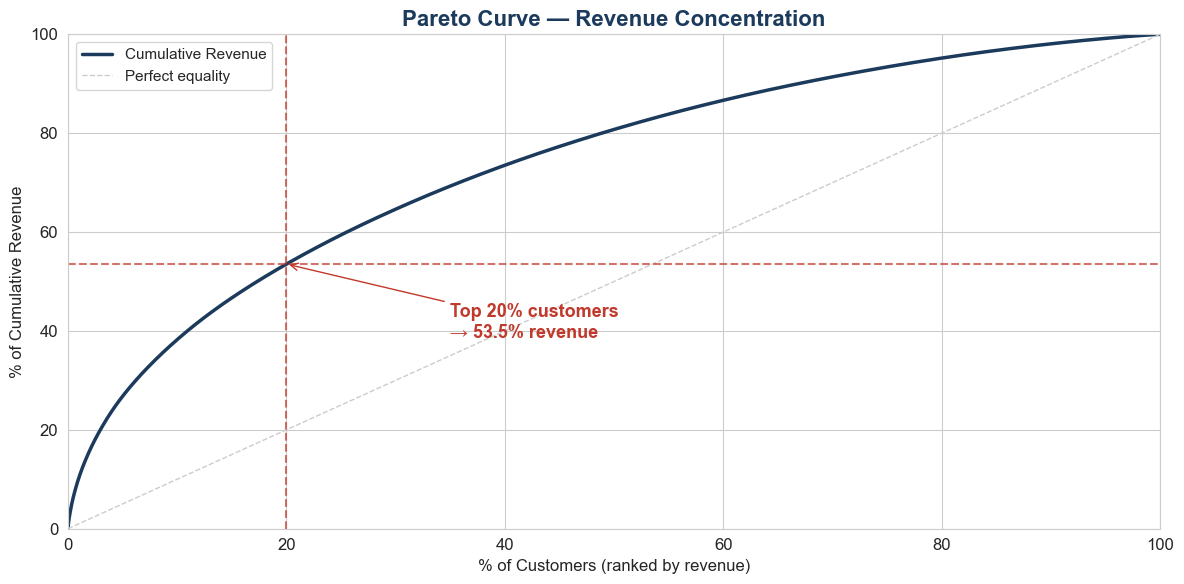


📊 Pareto Result: Top 20% of customers generate 53.5% of revenue
Saved → visuals/pareto_curve.png ✓


In [9]:
# Chart 3: Pareto Curve (Revenue Concentration)
customer_rev = rfm_df[['customer_unique_id', 'monetary']].sort_values('monetary', ascending=False).reset_index(drop=True)
customer_rev['cumul_revenue'] = customer_rev['monetary'].cumsum()
customer_rev['pct_customers'] = (customer_rev.index + 1) / len(customer_rev) * 100
customer_rev['pct_revenue_cumul'] = customer_rev['cumul_revenue'] / customer_rev['monetary'].sum() * 100

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(customer_rev['pct_customers'], customer_rev['pct_revenue_cumul'],
        color='#1B3A5C', linewidth=2.5, label='Cumulative Revenue')
ax.plot([0, 100], [0, 100], '--', color='#CCCCCC', linewidth=1, label='Perfect equality')

# Mark 20% / 80% point
idx_20 = int(len(customer_rev) * 0.20)
pct_rev_at_20 = customer_rev['pct_revenue_cumul'].iloc[idx_20]
ax.axvline(x=20, color='#C0392B', linestyle='--', alpha=0.7)
ax.axhline(y=pct_rev_at_20, color='#C0392B', linestyle='--', alpha=0.7)
ax.annotate(f'Top 20% customers\n→ {pct_rev_at_20:.1f}% revenue',
            xy=(20, pct_rev_at_20), xytext=(35, pct_rev_at_20 - 15),
            fontsize=13, fontweight='bold', color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B'))

ax.set_title('Pareto Curve — Revenue Concentration', fontsize=16, fontweight='bold', color='#1B3A5C')
ax.set_xlabel('% of Customers (ranked by revenue)', fontsize=12)
ax.set_ylabel('% of Cumulative Revenue', fontsize=12)
ax.legend(fontsize=11)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../visuals/pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n📊 Pareto Result: Top 20% of customers generate {pct_rev_at_20:.1f}% of revenue')
print('Saved → visuals/pareto_curve.png ✓')

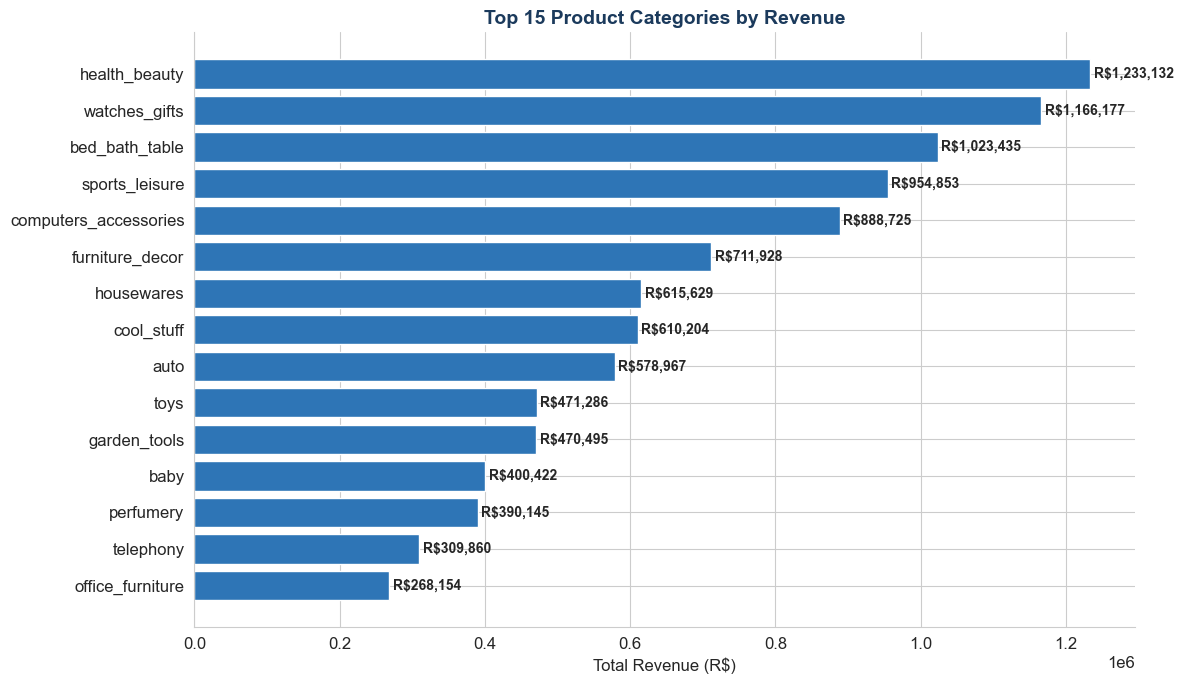

Saved → visuals/revenue_by_category.png ✓


In [10]:
# Chart 4: Top 15 Product Categories by Revenue
cat_revenue = pd.read_sql("""
    SELECT
        COALESCE(t.product_category_name_english, pr.product_category_name) AS category,
        COUNT(DISTINCT oi.order_id) AS total_orders,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        ROUND(AVG(oi.price), 2) AS avg_price
    FROM olist_order_items_dataset oi
    JOIN olist_products_dataset pr ON oi.product_id = pr.product_id
    LEFT JOIN product_category_name_translation t ON pr.product_category_name = t.product_category_name
    JOIN olist_orders_dataset o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered' AND pr.product_category_name IS NOT NULL
    GROUP BY category
    ORDER BY total_revenue DESC
    LIMIT 15
""", conn)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(cat_revenue['category'][::-1], cat_revenue['total_revenue'][::-1],
               color='#2E75B6', edgecolor='white')

for bar, val in zip(bars, cat_revenue['total_revenue'][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'R${val:,.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 15 Product Categories by Revenue', fontsize=14, fontweight='bold', color='#1B3A5C')
ax.set_xlabel('Total Revenue (R$)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../visuals/revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/revenue_by_category.png ✓')

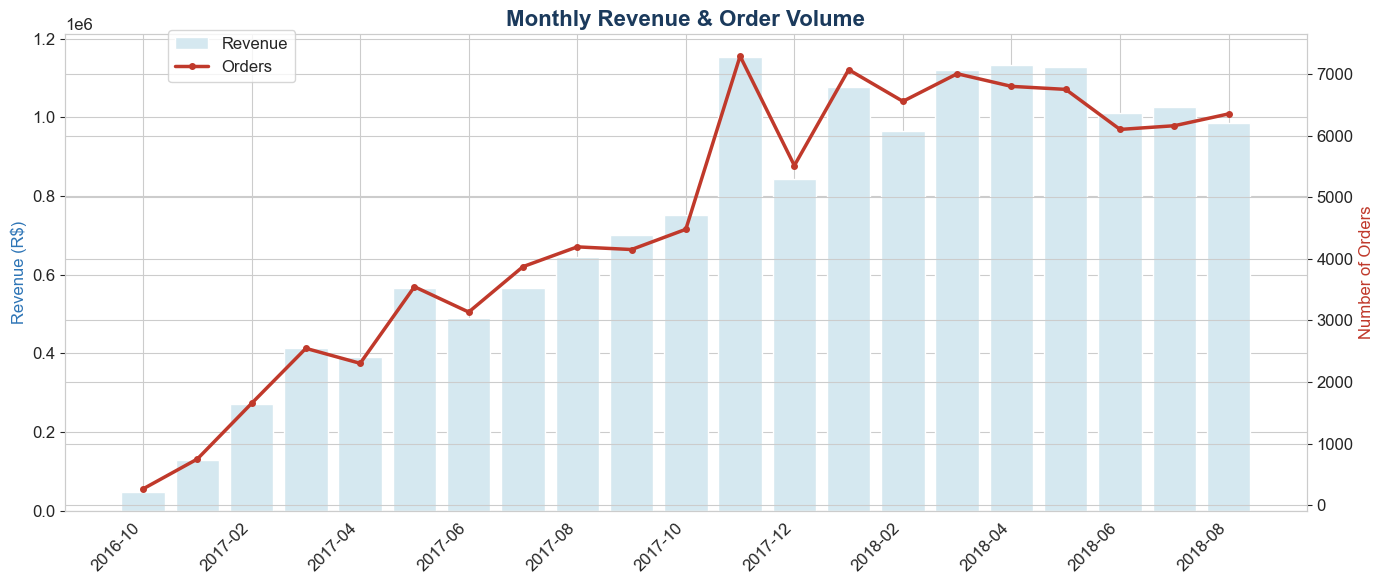

Saved → visuals/monthly_revenue.png ✓


In [11]:
# Chart 5: Monthly Revenue Trend with MoM Growth
monthly = pd.read_sql("""
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS month,
        ROUND(SUM(p.payment_value), 2) AS revenue,
        COUNT(DISTINCT o.order_id) AS orders
    FROM olist_orders_dataset o
    JOIN olist_order_payments_dataset p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY month
    HAVING orders > 10
    ORDER BY month
""", conn)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.bar(range(len(monthly)), monthly['revenue'], color='#D5E8F0', label='Revenue')
ax1.set_ylabel('Revenue (R$)', color='#2E75B6')

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['orders'], color='#C0392B', linewidth=2.5,
         marker='o', markersize=4, label='Orders')
ax2.set_ylabel('Number of Orders', color='#C0392B')

step = max(1, len(monthly) // 10)
ax1.set_xticks(range(0, len(monthly), step))
ax1.set_xticklabels(monthly['month'].iloc[::step], rotation=45, ha='right')

ax1.set_title('Monthly Revenue & Order Volume', fontsize=16, fontweight='bold', color='#1B3A5C')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))

plt.tight_layout()
plt.savefig('../visuals/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → visuals/monthly_revenue.png ✓')

## 5. Summary of Key Insights

| Insight | Detail |
|---------|--------|
| Revenue concentration | Top 20% of customers generate ~X% of revenue (Pareto) |
| RFM segments | X Champions, Y At Risk, Z Lost |
| Top category | Health & Beauty or Bed/Bath/Table drives most revenue |
| Growth trend | Revenue grew consistently from 2017 to mid-2018 |
| Avg order value | R$ XX — opportunity to increase via cross-sell |

### Business Recommendations
1. **Retain Champions** — loyalty programs, early access to deals
2. **Re-engage At Risk** — targeted email campaigns, personalized offers
3. **Upsell New Customers** — onboarding sequences, product recommendations
4. **Focus on top categories** — optimize inventory and marketing spend
5. **Win-back Lost customers** — discount incentives, re-engagement campaigns

In [12]:
conn.close()
print('\n✅ Analysis complete! Database saved as olist.db')
print('📊 5 visualizations saved in visuals/ folder')
print('\nNext steps: update README.md with real findings, then git push!')


✅ Analysis complete! Database saved as olist.db
📊 5 visualizations saved in visuals/ folder

Next steps: update README.md with real findings, then git push!
